# Лабораторная работа 12

Тема: **Vanilla GAN для генерации цифр MNIST в PyTorch**  
Формат: практическая работа с обязательными собственными экспериментами и комментариями.

> Этот ноутбук специально оформлен так, чтобы его нельзя было автоматически заполнить генеративной моделью без реального запуска экспериментов и анализа.  
> Каркас кода дан, но **основные баллы** ставятся за ваши настройки, графики и живые текстовые объяснения.


## 1. Ваше понимание задачи GAN (если не знаетет, что такое GAN - можно гуглить и спрашивать LLM)

Перед запуском кода опишите текущее понимание (8–12 предложений):

1. Для чего нужны генеративно‑состязательные сети (GAN) и чем их цель отличается от классической задачи классификации.  
2. Как вы интуитивно представляете «игру» генератора и дискриминатора: кто что пытается сделать и почему это неустойчивая задача.  
3. Каких визуальных артефактов вы ожидаете от **простого** Vanilla GAN на MNIST (размытость, странные гибриды цифр и т.п.).

Пишите своими словами, как если бы объясняли задачу одногруппнику.


In [1]:
intro_text = """
1) GAN нужны для генерации новых данных, похожих на реальные. В отличие от классификации, GAN пытается создавать новые изображения.
2) Генератор получает случайный шум и пытается превратить его в реалистичное изображение. 
Дискриминатор получает на вход как реальные картинки, так и изображения генератора, и должен определить, какие из них настоящие.
Генератор старается обмануть дискриминатор, а дискриминатор пытается не дать себя обмануть. 
Если один из них начинает обучаться слишком быстро, обучение может стать нестабильным, поэтому GAN считается довольно сложной моделью.
3) От простого Vanilla GAN на MNIST я ожидаю увидеть цифры, похожие на настоящие, но иногда размытые или искажённые.
"""
print(intro_text)


1) GAN нужны для генерации новых данных, похожих на реальные. В отличие от классификации, GAN пытается создавать новые изображения.
2) Генератор получает случайный шум и пытается превратить его в реалистичное изображение. 
Дискриминатор получает на вход как реальные картинки, так и изображения генератора, и должен определить, какие из них настоящие.
Генератор старается обмануть дискриминатор, а дискриминатор пытается не дать себя обмануть. 
Если один из них начинает обучаться слишком быстро, обучение может стать нестабильным, поэтому GAN считается довольно сложной моделью.
3) От простого Vanilla GAN на MNIST я ожидаю увидеть цифры, похожие на настоящие, но иногда размытые или искажённые.



## 2. Импорт, настройки и данные (MNIST)


In [1]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, utils

import matplotlib.pyplot as plt
import numpy as np
import os

MY_SEED = 11  # при своих экспериментах можете поменять, но зафиксируйте в отчёте
torch.manual_seed(MY_SEED)
np.random.seed(MY_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Устройство:", device)
print("MY_SEED =", MY_SEED)

# каталог для возможного сохранения картинок
os.makedirs("gan_samples", exist_ok=True)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # пиксели в [-1, 1]
])

batch_size = 64

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform,
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
print("Размер train:", len(train_dataset))

Устройство: cpu
MY_SEED = 11
Размер train: 60000


Посмотрим на несколько реальных изображений, которые GAN должен научиться имитировать.


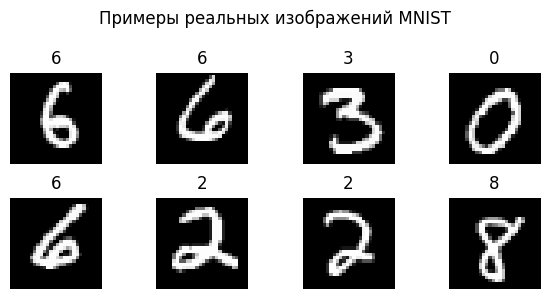

In [3]:
real_images, real_labels = next(iter(train_loader))
plt.figure(figsize=(6, 3))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(real_images[i].squeeze(0), cmap="gray")
    plt.title(str(real_labels[i].item()))
    plt.axis("off")
plt.suptitle("Примеры реальных изображений MNIST")
plt.tight_layout()
plt.show()

### Мини‑комментарий по данным

Кратко (3–5 предложений) опишите:
- насколько, на ваш взгляд, легко/сложно генератору научиться имитировать такие цифры;  
- какие особенности рукописных цифр могут затруднить генерацию (разные стили, толщина линий и т.п.).


In [4]:
data_comment = """
MNIST выглядит довольно простым датасетом для генерации, так как изображения маленькие и содержат только цифры. 
Главная сложность в том, что одну и ту же цифру люди пишут по-разному. Как например 2 или 6. 
Кроме того, отличаются толщина линий, наклон и форма цифр.
Из-за этого генератору может быть сложно создавать чёткие и одинаково качественные изображения всех цифр.
"""
print(data_comment)


MNIST выглядит довольно простым датасетом для генерации, так как изображения маленькие и содержат только цифры. 
Главная сложность в том, что одну и ту же цифру люди пишут по-разному. Как например 2 или 6. 
Кроме того, отличаются толщина линий, наклон и форма цифр.
Из-за этого генератору может быть сложно создавать чёткие и одинаково качественные изображения всех цифр.



## 3. Архитектура генератора и дискриминатора

Используем классический Vanilla GAN с полносвязными сетями:
- Генератор: принимает случайный шум `z` размерности 100 и выдаёт изображение 28×28 (через `tanh`, в диапазоне [-1, 1]);  
- Дискриминатор: принимает изображение 28×28 и выдаёт вероятность того, что оно "реальное".


In [2]:
z_dim = 100
img_dim = 28 * 28

class Generator(nn.Module):
    def __init__(self, z_dim, img_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(z_dim, 256),
            nn.ReLU(True),
            nn.Linear(256, 512),
            nn.ReLU(True),
            nn.Linear(512, 1024),
            nn.ReLU(True),
            nn.Linear(1024, img_dim),
            nn.Tanh()
        )

    def forward(self, z):
        img = self.net(z)
        img = img.view(-1, 1, 28, 28)
        return img


class Discriminator(nn.Module):
    def __init__(self, img_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(img_dim, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)


G = Generator(z_dim, img_dim).to(device)
D = Discriminator(img_dim).to(device)

print(G)
print(D)

Generator(
  (net): Sequential(
    (0): Linear(in_features=100, out_features=256, bias=True)
    (1): ReLU(inplace=True)
    (2): Linear(in_features=256, out_features=512, bias=True)
    (3): ReLU(inplace=True)
    (4): Linear(in_features=512, out_features=1024, bias=True)
    (5): ReLU(inplace=True)
    (6): Linear(in_features=1024, out_features=784, bias=True)
    (7): Tanh()
  )
)
Discriminator(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=512, bias=True)
    (2): LeakyReLU(negative_slope=0.2, inplace=True)
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Linear(in_features=256, out_features=1, bias=True)
    (6): Sigmoid()
  )
)


### Краткий анализ архитектуры

Ответьте в 4–6 предложениях:
- почему в генераторе используется `tanh` на выходе и совместим ли он с нормализацией входных данных;  
- зачем в дискриминаторе используется `LeakyReLU`, а не обычный `ReLU`.


In [6]:
arch_comment = """
1) На выходе генератора используется tanh, потому что она выдаёт значения
от -1 до 1 и хорошо подходит для нормализованных изображений.

2) В дискриминаторе используется LeakyReLU, чтобы нейроны продолжали обучаться
даже при отрицательных значениях. Обычный ReLU чаще используют в простых сетях,
а LeakyReLU полезен, когда важно избежать "мёртвых" нейронов и сделать обучение
более стабильным.
"""
print(arch_comment)


1) На выходе генератора используется tanh, потому что она выдаёт значения
от -1 до 1 и хорошо подходит для нормализованных изображений.

2) В дискриминаторе используется LeakyReLU, чтобы нейроны продолжали обучаться
даже при отрицательных значениях. Обычный ReLU чаще используют в простых сетях,
а LeakyReLU полезен, когда важно избежать "мёртвых" нейронов и сделать обучение
более стабильным.



## 4. Функция потерь, оптимизаторы и фиксированный шум

Используем бинарную кросс‑энтропию и два оптимизатора Adam (для G и D).


In [3]:
criterion = nn.BCELoss()

lr = 2e-4
beta1 = 0.5

opt_G = torch.optim.Adam(G.parameters(), lr=lr, betas=(beta1, 0.999))
opt_D = torch.optim.Adam(D.parameters(), lr=lr, betas=(beta1, 0.999))

# фиксированный шум для отслеживания прогресса генератора
fixed_z = torch.randn(64, z_dim, device=device)
print("fixed_z shape:", fixed_z.shape)

fixed_z shape: torch.Size([64, 100])


## 5. Цикл обучения GAN с журналированием лоссов

На каждой итерации:

1. Обновляем дискриминатор: считаем лосс на реальных и сгенерированных изображениях.  
2. Обновляем генератор: генерируем фейки и стараемся заставить дискриминатор считать их реальными.


Эпоха 1/30 | loss_G=1.5685, loss_D=1.0452


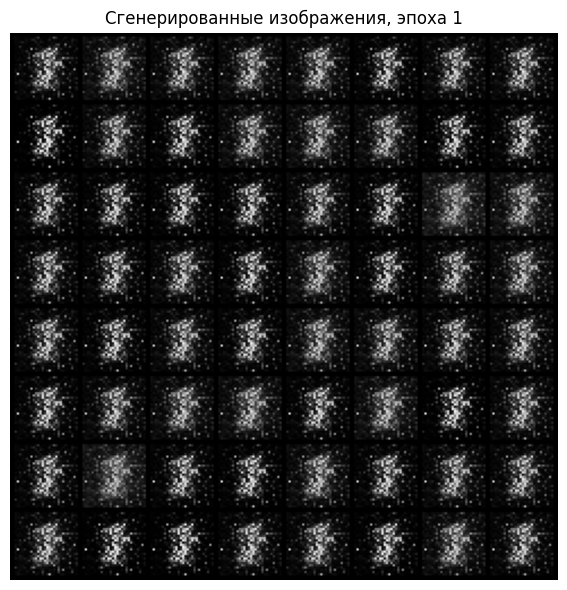

Эпоха 2/30 | loss_G=2.8970, loss_D=0.6446
Эпоха 3/30 | loss_G=3.2688, loss_D=0.6025
Эпоха 4/30 | loss_G=3.4270, loss_D=0.5956
Эпоха 5/30 | loss_G=3.5985, loss_D=0.5330


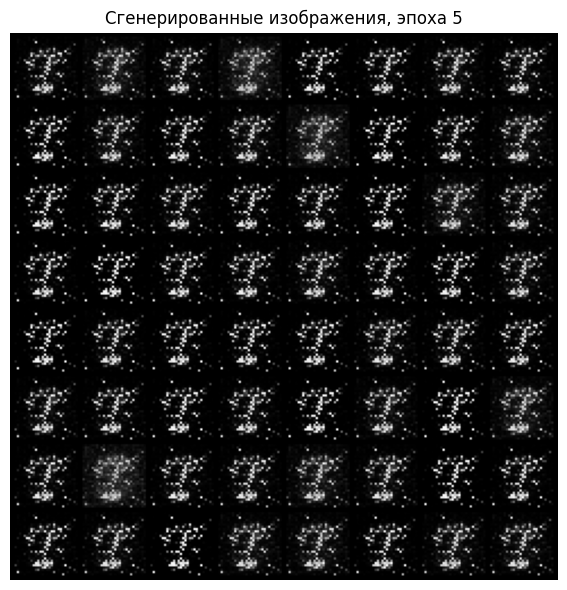

Эпоха 6/30 | loss_G=3.9480, loss_D=0.5028
Эпоха 7/30 | loss_G=3.8530, loss_D=0.4892
Эпоха 8/30 | loss_G=42.7513, loss_D=0.0771
Эпоха 9/30 | loss_G=17.3166, loss_D=0.4352
Эпоха 10/30 | loss_G=4.3217, loss_D=0.2836


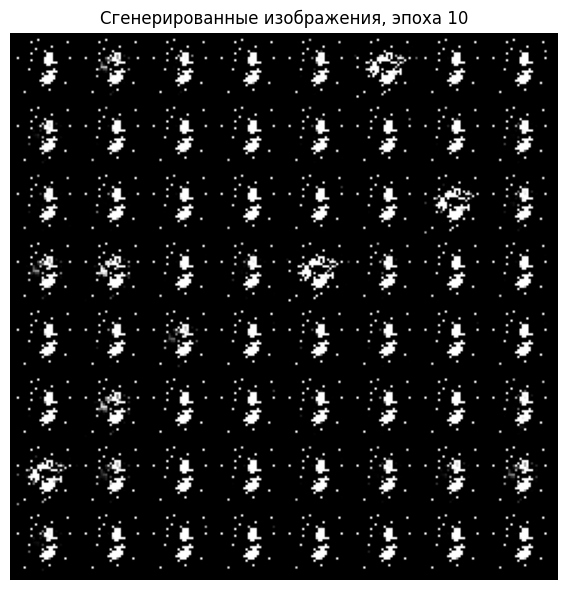

Эпоха 11/30 | loss_G=5.8609, loss_D=0.1341
Эпоха 12/30 | loss_G=32.0154, loss_D=0.0039
Эпоха 13/30 | loss_G=19.9803, loss_D=0.0096
Эпоха 14/30 | loss_G=7.9522, loss_D=0.0257
Эпоха 15/30 | loss_G=9.3335, loss_D=0.0048


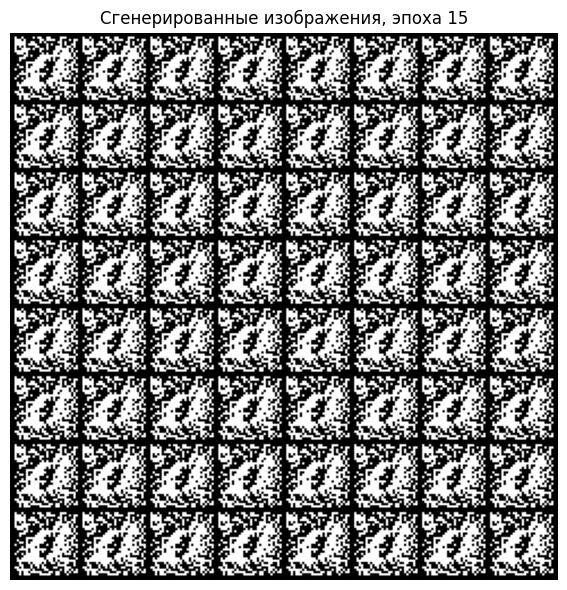

Эпоха 16/30 | loss_G=12.1130, loss_D=0.0000
Эпоха 17/30 | loss_G=13.1118, loss_D=0.0000
Эпоха 18/30 | loss_G=45.4743, loss_D=0.0001
Эпоха 19/30 | loss_G=67.8667, loss_D=0.0000
Эпоха 20/30 | loss_G=67.8549, loss_D=0.0000


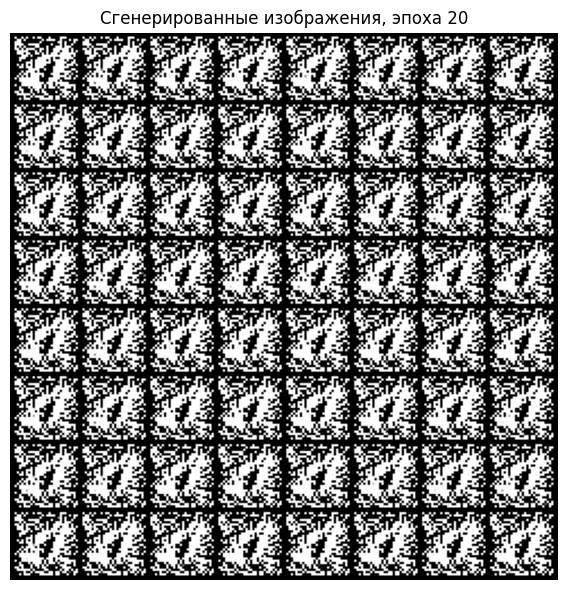

Эпоха 22/30 | loss_G=67.8465, loss_D=0.0000
Эпоха 23/30 | loss_G=67.8485, loss_D=0.0000
Эпоха 24/30 | loss_G=67.8666, loss_D=0.0000
Эпоха 25/30 | loss_G=67.8580, loss_D=0.0000


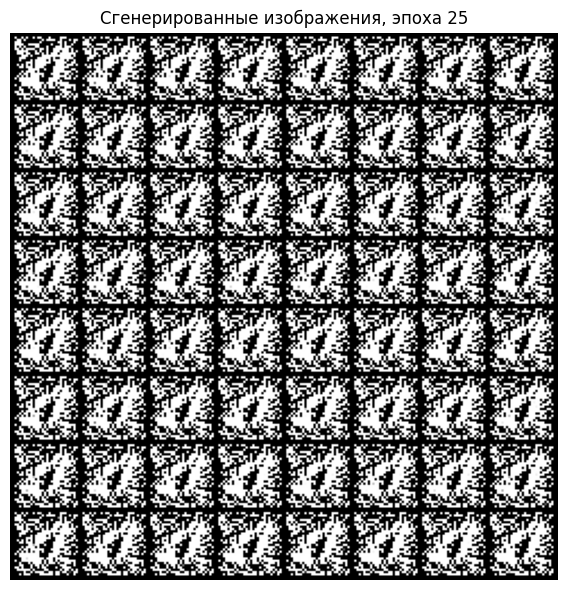

Эпоха 26/30 | loss_G=67.8589, loss_D=0.0000
Эпоха 27/30 | loss_G=67.8603, loss_D=0.0000
Эпоха 28/30 | loss_G=67.8585, loss_D=0.0000
Эпоха 29/30 | loss_G=67.8589, loss_D=0.0000
Эпоха 30/30 | loss_G=67.8659, loss_D=0.0000


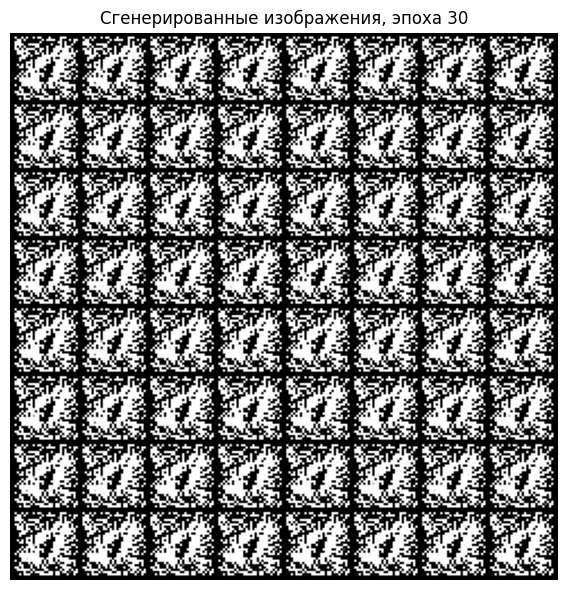

In [8]:
def train_gan(num_epochs):
    G.train()
    D.train()

    loss_history_G = []
    loss_history_D = []

    for epoch in range(1, num_epochs + 1):
        epoch_loss_G = 0.0
        epoch_loss_D = 0.0
        n_batches = 0

        for real_imgs, _ in train_loader:
            real_imgs = real_imgs.to(device)
            bs = real_imgs.size(0)

            # --- шаг дискриминатора ---
            real_labels = torch.ones(bs, 1, device=device)
            fake_labels = torch.zeros(bs, 1, device=device)

            # реал
            D_real = D(real_imgs)
            loss_D_real = criterion(D_real, real_labels)

            # фейк (detach, чтобы не обновлять G)
            z = torch.randn(bs, z_dim, device=device)
            fake_imgs = G(z).detach()
            D_fake = D(fake_imgs)
            loss_D_fake = criterion(D_fake, fake_labels)

            loss_D = loss_D_real + loss_D_fake

            opt_D.zero_grad()
            loss_D.backward()
            opt_D.step()

            # --- шаг генератора ---
            z = torch.randn(bs, z_dim, device=device)
            fake_imgs = G(z)
            D_fake_for_G = D(fake_imgs)
            loss_G = criterion(D_fake_for_G, real_labels)  # хотим метку 1 для фейков

            opt_G.zero_grad()
            loss_G.backward()
            opt_G.step()

            epoch_loss_G += loss_G.item()
            epoch_loss_D += loss_D.item()
            n_batches += 1

        avg_loss_G = epoch_loss_G / n_batches
        avg_loss_D = epoch_loss_D / n_batches
        loss_history_G.append(avg_loss_G)
        loss_history_D.append(avg_loss_D)

        print(f"Эпоха {epoch}/{num_epochs} | loss_G={avg_loss_G:.4f}, loss_D={avg_loss_D:.4f}")

        # визуальный мониторинг качества генератора
        if epoch % 5 == 0 or epoch == 1:
            G.eval()
            with torch.no_grad():
                samples = G(fixed_z).cpu()
            G.train()

            grid = utils.make_grid(samples, nrow=8, normalize=True, value_range=(-1, 1))
            plt.figure(figsize=(6, 6))
            plt.imshow(np.transpose(grid.numpy(), (1, 2, 0)))
            plt.axis("off")
            plt.title(f"Сгенерированные изображения, эпоха {epoch}")
            plt.tight_layout()
            plt.show()

    return loss_history_G, loss_history_D

num_epochs = 30  # в отчёте попробуйте другие значения и сравните
loss_G, loss_D = train_gan(num_epochs)

## 6. Графики лоссов генератора и дискриминатора

Посмотрим, как ведут себя лоссы G и D по эпохам.


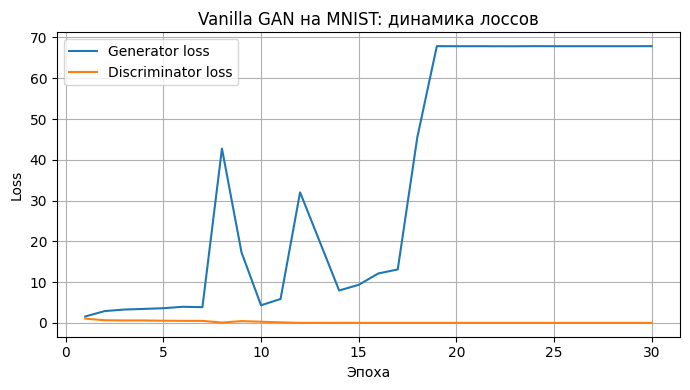

In [9]:
epochs_arr = np.arange(1, num_epochs + 1)

plt.figure(figsize=(7, 4))
plt.plot(epochs_arr, loss_G, label="Generator loss")
plt.plot(epochs_arr, loss_D, label="Discriminator loss")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.title("Vanilla GAN на MNIST: динамика лоссов")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### Анализ кривых лоссов

Опишите:
- есть ли тенденция к какому‑то «равновесию» между лоссами генератора и дискриминатора;  
- наблюдаются ли периодические колебания (кто «побеждает» на разных этапах обучения);  
- насколько реальное поведение лоссов совпало с вашими ожиданиями из раздела 1.


In [ ]:
loss_comment = """
1) В начале обучение дискриминатор учился быстрее: loss_D постепенно падал, а loss_G рос.
К 8 эпохе loss_G резко прыгнул, а loss_D почти стал нулевым. 
После 15 эпохи дискриминатор полностью доминирует, loss_D≈0, а loss_G очень большой и не меняется.
2) Периодические колебания есть только в начале. Потом генератор начал выдавать однотипные изображения с шумом.
На изображениях все цифры выглядят одинаково, как 4.
3) Мои ожидания не совпали. Я ожидала увидеть цифры, похожие на настоящие, пусть и немного размытые. 
Но увидела непонятные размазанные изображения. 
"""
print(loss_comment)

## 7. Финальная генерация изображений и визуальная оценка

Сгенерируем новые изображения из случайного шума и посмотрим, насколько они похожи на реальный MNIST.


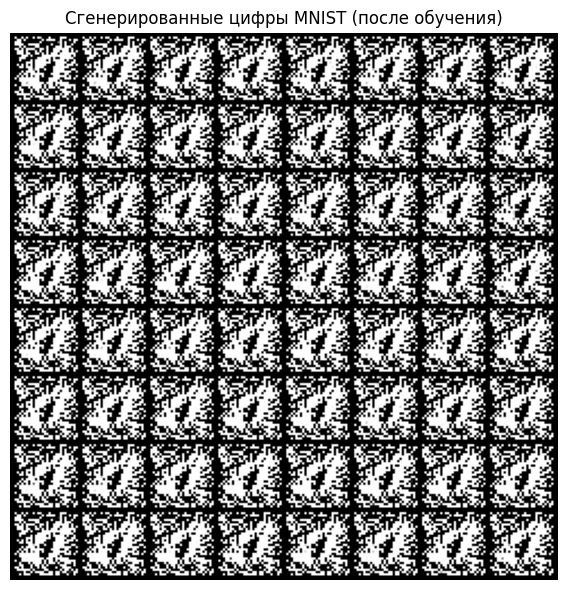

In [11]:
G.eval()
with torch.no_grad():
    z = torch.randn(64, z_dim, device=device)
    gen_imgs = G(z).cpu()

grid = utils.make_grid(gen_imgs, nrow=8, normalize=True, value_range=(-1, 1))
plt.figure(figsize=(6, 6))
plt.imshow(np.transpose(grid.numpy(), (1, 2, 0)))
plt.axis("off")
plt.title("Сгенерированные цифры MNIST (после обучения)")
plt.tight_layout()
plt.show()

### Оценка качества сгенерированных цифр

Опишите:
- какие цифры получаются наиболее убедительными, а какие чаще всего выглядят как «шум» или гибриды;  
- встречаются ли явно «несуществующие» объекты, не похожие ни на одну цифру, и как часто;  
- как вы думаете, на что сильнее всего влияет качество: глубина сетей, размер `z_dim`, число эпох, баланс обучения G/D.


In [ ]:
gen_quality_comment = """
Все изображения выглядят одинаково как размытые 4. Все изображения шумные. 
Разнообразие цифр полностью отсутствует. Я думаю, дискриминатор слишком сильный, генератор не успевает учится.
При слабом генераторе или маленьком z_dim цифры получаются размытыми.
"""
print(gen_quality_comment)

## 8. Идеи для вариаций в вашей работе

В **своём** варианте вы должны:

- попробовать **минимум две вариации** архитектуры (например, изменить размеры слоёв в G/D, добавить BatchNorm1d в генератор или заменить ReLU на LeakyReLU, добавить Dropout в дискриминатор) и сравнить визуально качество сгенерированных цифр;  
- поэкспериментировать с `z_dim` (например, 40-50-100) и описать, как это влияет на разнообразие и качество;  
- изменить число эпох/learning rate (возможно, задать разные lr для дискриминатора и генератора) и описать, как меняется динамика лоссов и итоговый результат.

GeneratorBN + DiscriminatorDropout
[V1] Эпоха 1/15 | G=1.1981, D=1.1417
[V1] Эпоха 2/15 | G=1.2917, D=1.1154
[V1] Эпоха 3/15 | G=1.2516, D=1.1165
[V1] Эпоха 4/15 | G=1.1229, D=1.1687
[V1] Эпоха 5/15 | G=1.0064, D=1.2148
[V1] Эпоха 6/15 | G=0.9373, D=1.2499
[V1] Эпоха 7/15 | G=0.8860, D=1.2800
[V1] Эпоха 8/15 | G=0.8541, D=1.2989
[V1] Эпоха 9/15 | G=0.8224, D=1.3179
[V1] Эпоха 10/15 | G=0.8040, D=1.3300
[V1] Эпоха 11/15 | G=0.7888, D=1.3395
[V1] Эпоха 12/15 | G=0.7726, D=1.3497
[V1] Эпоха 13/15 | G=0.7658, D=1.3546
[V1] Эпоха 14/15 | G=0.7572, D=1.3601
[V1] Эпоха 15/15 | G=0.7493, D=1.3630


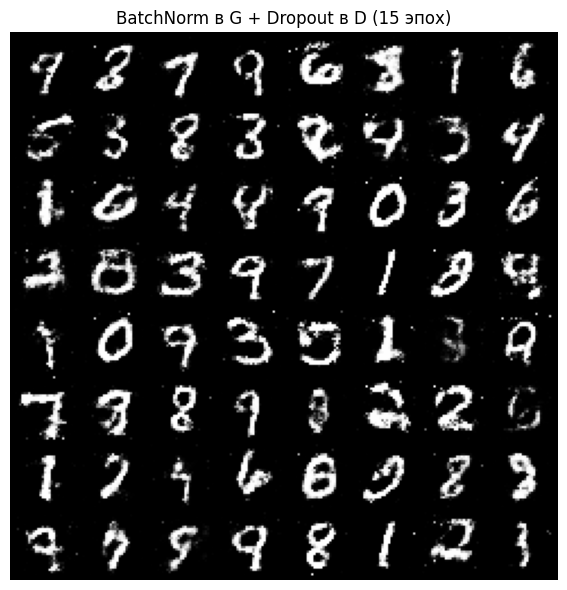

In [4]:
class GeneratorBN(nn.Module):
    def __init__(self, z_dim, img_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(z_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(True),
            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(True),
            nn.Linear(512, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(True),
            nn.Linear(1024, img_dim),
            nn.Tanh()
        )

    def forward(self, z):
        return self.net(z).view(-1, 1, 28, 28)


class DiscriminatorDropout(nn.Module):
    def __init__(self, img_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(img_dim, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)


print("GeneratorBN + DiscriminatorDropout")
G_v1 = GeneratorBN(z_dim, img_dim).to(device)
D_v1 = DiscriminatorDropout(img_dim).to(device)

opt_G_v1 = torch.optim.Adam(G_v1.parameters(), lr=lr, betas=(beta1, 0.999))
opt_D_v1 = torch.optim.Adam(D_v1.parameters(), lr=lr, betas=(beta1, 0.999))

num_epochs_v1 = 15
loss_G_v1_hist, loss_D_v1_hist = [], []

for epoch in range(1, num_epochs_v1 + 1):
    G_v1.train(); D_v1.train()
    ep_G, ep_D, nb = 0, 0, 0
    for real_imgs, _ in train_loader:
        real_imgs = real_imgs.to(device)
        bs = real_imgs.size(0)
        rl = torch.ones(bs, 1, device=device)
        fl = torch.zeros(bs, 1, device=device)

        z = torch.randn(bs, z_dim, device=device)
        fake = G_v1(z).detach()
        loss_D = criterion(D_v1(real_imgs), rl) + criterion(D_v1(fake), fl)
        opt_D_v1.zero_grad(); loss_D.backward(); opt_D_v1.step()

        z = torch.randn(bs, z_dim, device=device)
        loss_G = criterion(D_v1(G_v1(z)), rl)
        opt_G_v1.zero_grad(); loss_G.backward(); opt_G_v1.step()

        ep_G += loss_G.item(); ep_D += loss_D.item(); nb += 1

    loss_G_v1_hist.append(ep_G / nb)
    loss_D_v1_hist.append(ep_D / nb)
    print(f"[V1] Эпоха {epoch}/{num_epochs_v1} | G={ep_G/nb:.4f}, D={ep_D/nb:.4f}")

G_v1.eval()
with torch.no_grad():
    samples_v1 = G_v1(fixed_z).cpu()
grid_v1 = utils.make_grid(samples_v1, nrow=8, normalize=True, value_range=(-1, 1))
plt.figure(figsize=(6, 6))
plt.imshow(np.transpose(grid_v1.numpy(), (1, 2, 0)))
plt.axis("off")
plt.title("BatchNorm в G + Dropout в D (15 эпох)")
plt.tight_layout()
plt.show()

Эксперимент с z_dim
  z_dim=40, эпоха 1/10
  z_dim=40, эпоха 2/10
  z_dim=40, эпоха 3/10
  z_dim=40, эпоха 4/10
  z_dim=40, эпоха 5/10
  z_dim=40, эпоха 6/10
  z_dim=40, эпоха 7/10
  z_dim=40, эпоха 8/10
  z_dim=40, эпоха 9/10
  z_dim=40, эпоха 10/10


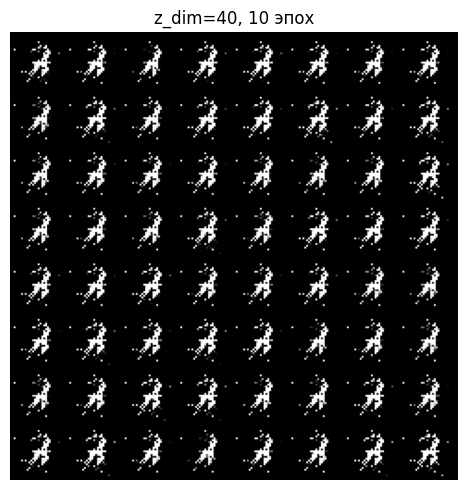

  z_dim=100, эпоха 1/10
  z_dim=100, эпоха 2/10
  z_dim=100, эпоха 3/10
  z_dim=100, эпоха 4/10
  z_dim=100, эпоха 5/10
  z_dim=100, эпоха 6/10
  z_dim=100, эпоха 7/10
  z_dim=100, эпоха 8/10
  z_dim=100, эпоха 9/10
  z_dim=100, эпоха 10/10


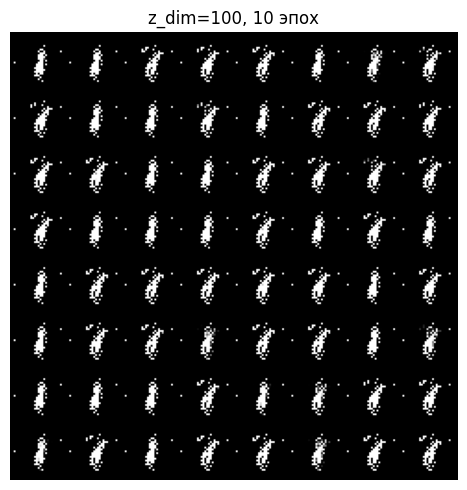

  z_dim=150, эпоха 1/10
  z_dim=150, эпоха 2/10
  z_dim=150, эпоха 3/10
  z_dim=150, эпоха 4/10
  z_dim=150, эпоха 5/10
  z_dim=150, эпоха 6/10
  z_dim=150, эпоха 7/10
  z_dim=150, эпоха 8/10
  z_dim=150, эпоха 9/10
  z_dim=150, эпоха 10/10


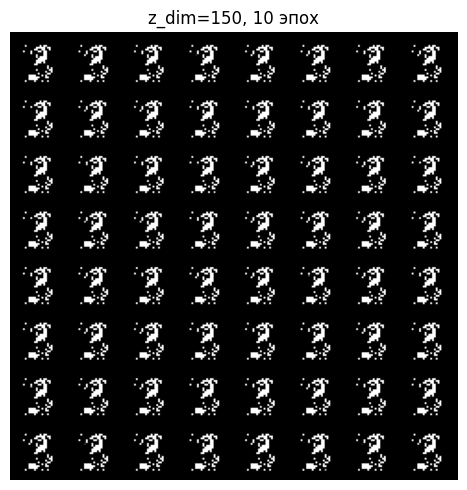

In [6]:
def run_zdim_experiment(zdim, epochs=10):
    G_exp = Generator(zdim, img_dim).to(device)
    D_exp = Discriminator(img_dim).to(device)
    opt_G_e = torch.optim.Adam(G_exp.parameters(), lr=lr, betas=(beta1, 0.999))
    opt_D_e = torch.optim.Adam(D_exp.parameters(), lr=lr, betas=(beta1, 0.999))
    test_z = torch.randn(64, zdim, device=device)

    for epoch in range(1, epochs + 1):
        G_exp.train(); D_exp.train()
        for real_imgs, _ in train_loader:
            real_imgs = real_imgs.to(device)
            bs = real_imgs.size(0)
            rl = torch.ones(bs, 1, device=device)
            fl = torch.zeros(bs, 1, device=device)

            z = torch.randn(bs, zdim, device=device)
            lD = criterion(D_exp(real_imgs), rl) + criterion(D_exp(G_exp(z).detach()), fl)
            opt_D_e.zero_grad(); lD.backward(); opt_D_e.step()

            z = torch.randn(bs, zdim, device=device)
            lG = criterion(D_exp(G_exp(z)), rl)
            opt_G_e.zero_grad(); lG.backward(); opt_G_e.step()

        print(f"  z_dim={zdim}, эпоха {epoch}/{epochs}")

    G_exp.eval()
    with torch.no_grad():
        imgs = G_exp(test_z).cpu()
    grid = utils.make_grid(imgs, nrow=8, normalize=True, value_range=(-1, 1))
    plt.figure(figsize=(5, 5))
    plt.imshow(np.transpose(grid.numpy(), (1, 2, 0)))
    plt.axis("off")
    plt.title(f"z_dim={zdim}, {epochs} эпох")
    plt.tight_layout()
    plt.show()


print("Эксперимент с z_dim")
for zdim in [40, 100, 150]:
    run_zdim_experiment(zdim, epochs=10)

lr_G=4e-4, lr_D=1e-4
[V3] Эпоха 1/15 | G=0.6809, D=1.3800
[V3] Эпоха 2/15 | G=0.7770, D=1.3479
[V3] Эпоха 3/15 | G=0.8346, D=1.3423
[V3] Эпоха 4/15 | G=0.8709, D=1.3192
[V3] Эпоха 5/15 | G=0.9065, D=1.3158
[V3] Эпоха 6/15 | G=0.9868, D=1.2416
[V3] Эпоха 7/15 | G=1.1091, D=1.2488
[V3] Эпоха 8/15 | G=1.0562, D=1.2211
[V3] Эпоха 9/15 | G=2.2492, D=0.7846
[V3] Эпоха 10/15 | G=3.9417, D=0.1983
[V3] Эпоха 11/15 | G=6.5334, D=0.0304
[V3] Эпоха 12/15 | G=6.8000, D=0.0224
[V3] Эпоха 13/15 | G=9.2036, D=0.0002
[V3] Эпоха 14/15 | G=10.6985, D=0.0000
[V3] Эпоха 15/15 | G=11.1106, D=0.0000


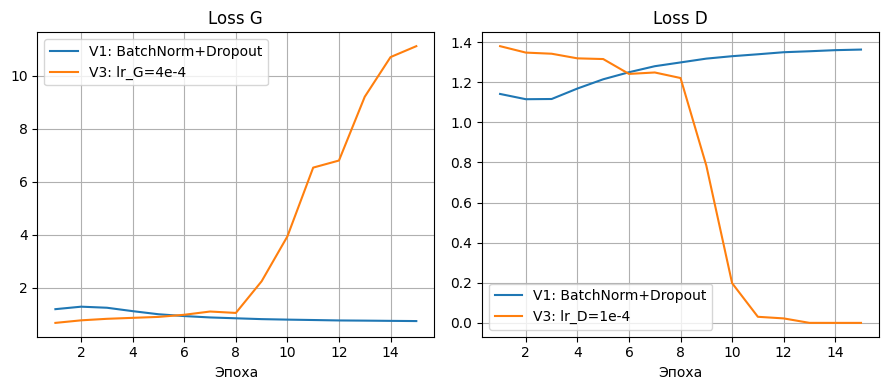

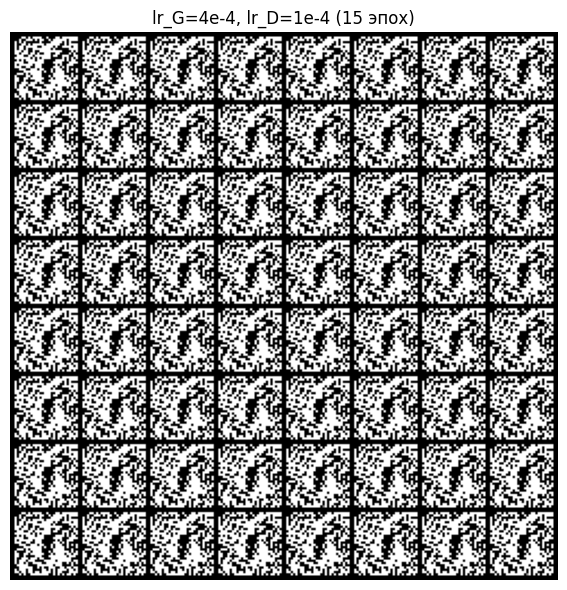

In [5]:
print("lr_G=4e-4, lr_D=1e-4")

G_v3 = Generator(z_dim, img_dim).to(device)
D_v3 = Discriminator(img_dim).to(device)

opt_G_v3 = torch.optim.Adam(G_v3.parameters(), lr=4e-4, betas=(beta1, 0.999))
opt_D_v3 = torch.optim.Adam(D_v3.parameters(), lr=1e-4, betas=(beta1, 0.999))

num_epochs_v3 = 15
loss_G_v3_hist, loss_D_v3_hist = [], []

for epoch in range(1, num_epochs_v3 + 1):
    G_v3.train(); D_v3.train()
    ep_G, ep_D, nb = 0, 0, 0
    for real_imgs, _ in train_loader:
        real_imgs = real_imgs.to(device)
        bs = real_imgs.size(0)
        rl = torch.ones(bs, 1, device=device)
        fl = torch.zeros(bs, 1, device=device)

        z = torch.randn(bs, z_dim, device=device)
        lD = criterion(D_v3(real_imgs), rl) + criterion(D_v3(G_v3(z).detach()), fl)
        opt_D_v3.zero_grad(); lD.backward(); opt_D_v3.step()

        z = torch.randn(bs, z_dim, device=device)
        lG = criterion(D_v3(G_v3(z)), rl)
        opt_G_v3.zero_grad(); lG.backward(); opt_G_v3.step()

        ep_G += lG.item(); ep_D += lD.item(); nb += 1

    loss_G_v3_hist.append(ep_G / nb)
    loss_D_v3_hist.append(ep_D / nb)
    print(f"[V3] Эпоха {epoch}/{num_epochs_v3} | G={ep_G/nb:.4f}, D={ep_D/nb:.4f}")

e_arr = np.arange(1, num_epochs_v3 + 1)
plt.figure(figsize=(9, 4))
plt.subplot(1, 2, 1)
plt.plot(e_arr, loss_G_v1_hist, label="V1: BatchNorm+Dropout")
plt.plot(e_arr, loss_G_v3_hist, label="V3: lr_G=4e-4")
plt.title("Loss G")
plt.xlabel("Эпоха"); plt.legend(); plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(e_arr, loss_D_v1_hist, label="V1: BatchNorm+Dropout")
plt.plot(e_arr, loss_D_v3_hist, label="V3: lr_D=1e-4")
plt.title("Loss D")
plt.xlabel("Эпоха"); plt.legend(); plt.grid(True)
plt.tight_layout()
plt.show()

G_v3.eval()
with torch.no_grad():
    samples_v3 = G_v3(fixed_z).cpu()
grid_v3 = utils.make_grid(samples_v3, nrow=8, normalize=True, value_range=(-1, 1))
plt.figure(figsize=(6, 6))
plt.imshow(np.transpose(grid_v3.numpy(), (1, 2, 0)))
plt.axis("off")
plt.title("lr_G=4e-4, lr_D=1e-4 (15 эпох)")
plt.tight_layout()
plt.show()

In [13]:
final_summary = """
Лучший результат дал вариант с BatchNorm в генераторе и Dropout в дискриминаторе.
Сгенерированные цифры получились наиболее похожими на реальные и достаточно разнообразными.
Эксперимент с z_dim показал, что увеличение размерности шума само по себе не гарантирует лучшее качество. 
При z_dim=40, 100 и 150 модель часто генерировала похожие изображения.
Самым неудачным оказался вариант с lr_G=4e-4 и lr_D=1e-4. Loss генератора резко вырос, loss дискриминатора упал почти до нуля, а изображения превратились в шум.
Главный вывод: BatchNorm и Dropout помогают сделать обучение стабильнее, а качество нужно
оценивать не только по loss, но и по самим сгенерированным изображениям.
"""
print(final_summary)

КОГДА ВЫ СДЕЛАЕТЕ СВОИ ВАРИАЦИИ GAN (АРХИТЕКТУРА, z_dim,
ГИПЕРПАРАМЕТРЫ), ИСПОЛЬЗУЙТЕ ЭТУ ЯЧЕЙКУ, ЧТОБЫ СФОРМУЛИРОВАТЬ ИТОГОВЫЕ
ВЫВОДЫ: КАКИЕ НАСТРОЙКИ ДАЮТ ЛУЧШЕЕ СОЧЕТАНИЕ СТАБИЛЬНОСТИ ОБУЧЕНИЯ И
КАЧЕСТВА СГЕНЕРИРОВАННЫХ ЦИФР, И КАКИЕ ПРАКТИЧЕСКИЕ ПРАВИЛА ВЫ ДЛЯ СЕБЯ
ВЫВЕЛИ ДЛЯ НАСТРОЙКИ VANILLA GAN НА MNIST.
